# DESI Spectra Exploration Notebook

This notebook downloads, loads, filters, and visualizes real DESI spectra from the Early Data Release (EDR).

**What we do:**
1. Download a small subset of DESI coadd + redrock files
2. Load and stitch B/R/Z camera bands
3. Filter out bad spectra (bad fiber status, bad redshifts, zero flux)
4. Plot spectra with object type labels
5. Plot redshift distribution

**Data source:** DESI EDR SV3 "one-percent" survey — real astronomical data, not synthetic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import requests
from IPython.display import display, Image

# Set plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")

Libraries imported successfully


## Step 1: Download Real DESI Data

We download a single healpix pixel from the DESI EDR. This contains ~43 spectra, but after quality filtering we'll keep ~25 good ones.

Files downloaded:
- `coadd-sv3-bright-10016.fits` — coadded spectra (18.5 MB)
- `redrock-sv3-bright-10016.fits` — redshift measurements + object types (96 KB)

In [2]:
data_dir = Path("../data/desi_raw")
data_dir.mkdir(parents=True, exist_ok=True)

base_url = "https://data.desi.lbl.gov/public/edr/spectro/redux/fuji/healpix/sv3/bright/100/10016/"

files = {
    "coadd-sv3-bright-10016.fits": "coadd file (spectra)",
    "redrock-sv3-bright-10016.fits": "redrock file (redshifts + types)",
}

for filename, description in files.items():
    filepath = data_dir / filename
    if filepath.exists():
        print(f"✓ {filename} already exists ({filepath.stat().st_size / 1024 / 1024:.1f} MB)")
        continue
    
    url = base_url + filename
    print(f"Downloading {filename}...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(filepath, "wb") as f:
        f.write(r.content)
    print(f"✓ Saved {filename} ({filepath.stat().st_size / 1024 / 1024:.1f} MB)")

print("\nAll files ready!")

✓ coadd-sv3-bright-10016.fits already exists (18.5 MB)
✓ redrock-sv3-bright-10016.fits already exists (0.1 MB)

All files ready!


## Step 2: Inspect File Structure

Let's see what's inside the FITS files.

In [3]:
coadd_path = data_dir / "coadd-sv3-bright-10016.fits"
redrock_path = data_dir / "redrock-sv3-bright-10016.fits"

print("=== COADD FILE STRUCTURE ===")
with fits.open(coadd_path) as hdul:
    for hdu in hdul:
        shape = hdu.data.shape if hdu.data is not None else None
        print(f"  {hdu.name}: shape={shape}")

print("\n=== REDROCK FILE STRUCTURE ===")
with fits.open(redrock_path) as hdul:
    for hdu in hdul:
        shape = hdu.data.shape if hdu.data is not None else None
        print(f"  {hdu.name}: shape={shape}")
        if hdu.data is not None and hasattr(hdu.data, 'dtype'):
            print(f"    Columns: {list(hdu.data.dtype.names)}")

=== COADD FILE STRUCTURE ===
  PRIMARY: shape=None
  FIBERMAP: shape=(43,)
  EXP_FIBERMAP: shape=(127,)
  B_WAVELENGTH: shape=(2751,)
  B_FLUX: shape=(43, 2751)
  B_IVAR: shape=(43, 2751)
  B_MASK: shape=(43, 2751)
  B_RESOLUTION: shape=(43, 11, 2751)
  R_WAVELENGTH: shape=(2326,)
  R_FLUX: shape=(43, 2326)
  R_IVAR: shape=(43, 2326)
  R_MASK: shape=(43, 2326)
  R_RESOLUTION: shape=(43, 11, 2326)
  Z_WAVELENGTH: shape=(2881,)
  Z_FLUX: shape=(43, 2881)
  Z_IVAR: shape=(43, 2881)
  Z_MASK: shape=(43, 2881)
  Z_RESOLUTION: shape=(43, 11, 2881)
  SCORES: shape=(43,)

=== REDROCK FILE STRUCTURE ===
  PRIMARY: shape=None
  REDSHIFTS: shape=(43,)
    Columns: ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2']
  FIBERMAP: shape=(43,)
    Columns: ['TARGETID', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 'RELEASE', 'BRICKNAME', 'BRICKID',

## Step 3: Load Spectra and Quality Flags

We load the flux, inverse variance, mask, wavelength, redshift, and object type for each spectrum.

**Quality flags we check:**
- `COADD_FIBERSTATUS` — fiber hardware status (0 = good)
- `ZWARN` — redshift quality flag (0 = good redshift fit)
- Total flux — must be non-zero (some targets have no data at all)

In [4]:
def load_spectra(coadd_path, redrock_path, require_good=True):
    """Load spectra with quality filtering."""
    
    with fits.open(coadd_path) as ch, fits.open(redrock_path) as rh:
        n_total = ch["B_FLUX"].data.shape[0]
        
        # Read quality flags
        fiberstatus = ch["FIBERMAP"].data["COADD_FIBERSTATUS"]
        zwarn = rh["REDSHIFTS"].data["ZWARN"]
        redshifts = rh["REDSHIFTS"].data["Z"]
        spectypes = rh["REDSHIFTS"].data["SPECTYPE"]
        subtypes = rh["REDSHIFTS"].data["SUBTYPE"]
        
        # Wavelength grids
        b_wave = ch["B_WAVELENGTH"].data
        r_wave = ch["R_WAVELENGTH"].data
        z_wave = ch["Z_WAVELENGTH"].data
        
        spectra = []
        n_filtered = {"fiber": 0, "zwarn": 0, "flux": 0}
        
        for i in range(n_total):
            # Filter 1: Bad fiber status
            if require_good and fiberstatus[i] != 0:
                n_filtered["fiber"] += 1
                continue
            
            # Filter 2: Bad ZWARN
            if require_good and zwarn[i] != 0:
                n_filtered["zwarn"] += 1
                continue
            
            # Read flux
            b_flux = ch["B_FLUX"].data[i]
            r_flux = ch["R_FLUX"].data[i]
            z_flux = ch["Z_FLUX"].data[i]
            
            # Filter 3: Zero flux
            total_flux = np.abs(b_flux).sum() + np.abs(r_flux).sum() + np.abs(z_flux).sum()
            if require_good and total_flux == 0:
                n_filtered["flux"] += 1
                continue
            
            # Read ivar and mask
            b_ivar = ch["B_IVAR"].data[i]
            r_ivar = ch["R_IVAR"].data[i]
            z_ivar = ch["Z_IVAR"].data[i]
            
            b_mask = ch["B_MASK"].data[i] != 0
            r_mask = ch["R_MASK"].data[i] != 0
            z_mask = ch["Z_MASK"].data[i] != 0
            
            # Stitch bands
            all_wave = np.concatenate([b_wave, r_wave, z_wave])
            all_flux = np.concatenate([b_flux, r_flux, z_flux])
            all_ivar = np.concatenate([b_ivar, r_ivar, z_ivar])
            all_mask = np.concatenate([b_mask, r_mask, z_mask])
            
            sort_idx = np.argsort(all_wave)
            
            spectra.append({
                "wavelength": all_wave[sort_idx].astype(np.float32),
                "flux": all_flux[sort_idx].astype(np.float32),
                "ivar": all_ivar[sort_idx].astype(np.float32),
                "mask": all_mask[sort_idx],
                "z": float(redshifts[i]),
                "spectype": spectypes[i],
                "subtype": subtypes[i],
                "zwarn": int(zwarn[i]),
                "fiberstatus": int(fiberstatus[i]),
                "index": i,
            })
        
        print(f"Total spectra in file: {n_total}")
        if require_good:
            total_filtered = sum(n_filtered.values())
            print(f"Filtered out: {total_filtered}")
            print(f"  - Bad fiber status: {n_filtered['fiber']}")
            print(f"  - Bad ZWARN:        {n_filtered['zwarn']}")
            print(f"  - Zero flux:        {n_filtered['flux']}")
            print(f"Good spectra: {len(spectra)}")
        
        return spectra

spectra = load_spectra(coadd_path, redrock_path, require_good=True)

Total spectra in file: 43
Filtered out: 18
  - Bad fiber status: 18
  - Bad ZWARN:        0
  - Zero flux:        0
Good spectra: 25


## Step 4: Summarize Object Types

What kinds of objects are in our sample?

In [5]:
from collections import Counter

print("=== OBJECT TYPE BREAKDOWN ===\n")

type_counts = Counter([s["spectype"] for s in spectra])
for spectype, count in type_counts.most_common():
    print(f"{spectype}: {count}")

print("\n=== FIRST 10 OBJECTS ===\n")
for s in spectra[:10]:
    print(f"  [{s['index']:2d}] {s['spectype']:6s} | z={s['z']:7.4f} | subtype={s['subtype']:6s}")

print(f"\nRedshift range: [{min(s['z'] for s in spectra):.4f}, {max(s['z'] for s in spectra):.4f}]")

=== OBJECT TYPE BREAKDOWN ===

GALAXY: 19
STAR: 5
QSO: 1

=== FIRST 10 OBJECTS ===

  [ 0] GALAXY | z= 0.2004 | subtype=      
  [ 1] GALAXY | z= 0.5871 | subtype=      
  [ 2] GALAXY | z= 0.1146 | subtype=      
  [ 3] STAR   | z=-0.0001 | subtype=K     
  [ 4] GALAXY | z= 0.2646 | subtype=      
  [ 5] GALAXY | z= 0.9900 | subtype=      
  [ 7] GALAXY | z= 0.3459 | subtype=      
  [ 9] GALAXY | z= 0.2007 | subtype=      
  [10] QSO    | z= 0.2653 | subtype=      
  [11] GALAXY | z= 0.1153 | subtype=      

Redshift range: [-0.0008, 0.9900]


## Step 5: Plot Individual Spectra with Labels

Each panel shows:
- **Black line**: Flux
- **Gray shading**: 1σ noise level (from inverse variance)
- **Vertical lines**: Masked (bad) pixels
- **Title**: Object type, redshift, and subtype

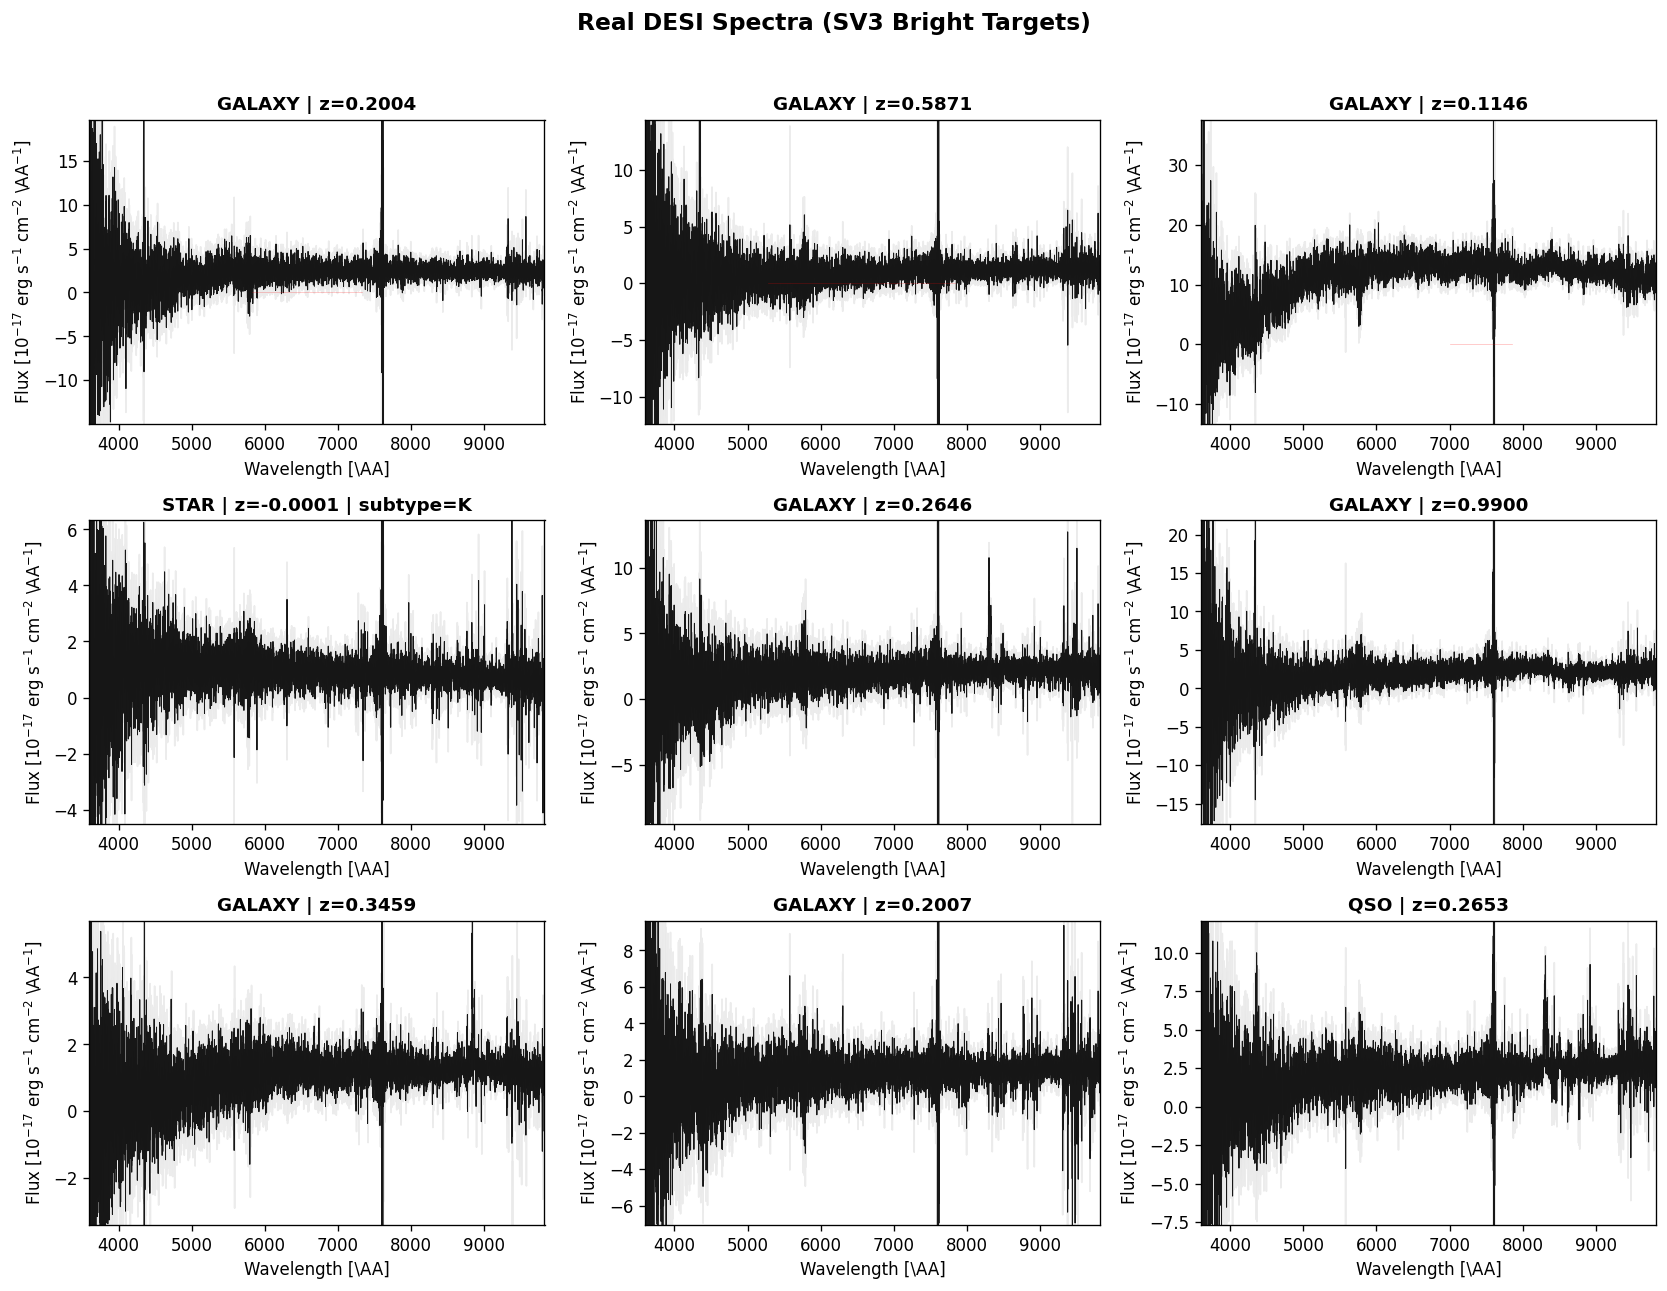


Plotted 9 spectra. Each panel is labeled with: OBJECT_TYPE | z=REDSHIFT | subtype=SUBTYPE


In [6]:
def plot_spectrum(spec, ax=None, show_errors=True):
    """Plot a single labeled spectrum."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3.5))
    
    wave = spec["wavelength"]
    flux = spec["flux"]
    ivar = spec["ivar"]
    mask = spec["mask"]
    
    # Plot good pixels
    good = ~mask
    ax.plot(wave[good], flux[good], color="black", linewidth=0.6, alpha=0.9)
    
    # Plot masked pixels in red
    if (~good).any():
        ax.plot(wave[~good], flux[~good], color="red", linewidth=0.4, alpha=0.3)
    
    # Error region
    if show_errors and ivar is not None:
        sigma = 1.0 / np.sqrt(ivar[good] + 1e-20)
        ax.fill_between(
            wave[good], flux[good] - sigma, flux[good] + sigma,
            alpha=0.15, color="gray",
        )
    
    # Title with object info
    title = f"{spec['spectype']} | z={spec['z']:.4f}"
    if spec['subtype']:
        title += f" | subtype={spec['subtype']}"
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    ax.set_xlabel(r"Wavelength [\AA]")
    ax.set_ylabel(r"Flux [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ \AA$^{-1}$]")
    ax.set_xlim(wave.min(), wave.max())
    
    # Auto-scale y
    y_good = flux[good] if good.any() else flux
    if len(y_good) > 0:
        y_med = np.median(y_good)
        y_std = np.std(y_good)
        ax.set_ylim(y_med - 5*y_std, y_med + 5*y_std)
    
    return ax


# Plot first 9 spectra in a grid
n_plot = min(9, len(spectra))
ncols = 3
nrows = (n_plot + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5*nrows), squeeze=False)

for i in range(n_plot):
    row = i // ncols
    col = i % ncols
    plot_spectrum(spectra[i], ax=axes[row, col])

# Hide unused subplots
for i in range(n_plot, nrows * ncols):
    axes[i // ncols, i % ncols].axis("off")

plt.suptitle("Real DESI Spectra (SV3 Bright Targets)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nPlotted {n_plot} spectra. Each panel is labeled with: OBJECT_TYPE | z=REDSHIFT | subtype=SUBTYPE")

## Step 6: Plot Redshift Distribution by Object Type

Color-coded by object type (STAR, GALAXY, QSO).

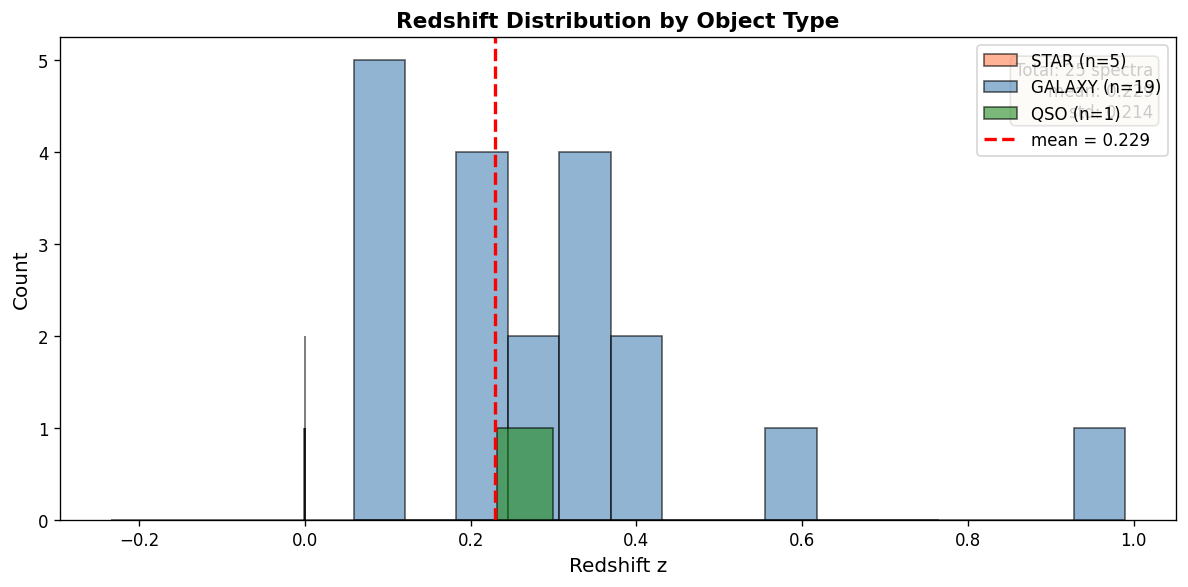


Key observations:
  - STARS cluster at z ≈ 0 (they are in our galaxy, not cosmologically redshifted)
  - GALAXIES span z = 0.1–1.0 (cosmological distances)
  - QSOs (quasars) are rare in bright targets


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Color by type
colors = {"STAR": "coral", "GALAXY": "steelblue", "QSO": "forestgreen"}

for spectype in ["STAR", "GALAXY", "QSO"]:
    zs = [s["z"] for s in spectra if s["spectype"] == spectype]
    if zs:
        ax.hist(
            zs, bins=15, alpha=0.6, color=colors.get(spectype, "gray"),
            edgecolor="black", label=f"{spectype} (n={len(zs)})",
        )

all_z = [s["z"] for s in spectra]
ax.axvline(np.mean(all_z), color="red", linestyle="--", linewidth=2, label=f"mean = {np.mean(all_z):.3f}")

ax.set_xlabel("Redshift z", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Redshift Distribution by Object Type", fontsize=13, fontweight='bold')
ax.legend(loc="upper right")
ax.text(
    0.98, 0.95,
    f"Total: {len(spectra)} spectra\nmean: {np.mean(all_z):.3f}\nstd: {np.std(all_z):.3f}",
    transform=ax.transAxes, fontsize=10,
    verticalalignment="top", horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  - STARS cluster at z ≈ 0 (they are in our galaxy, not cosmologically redshifted)")
print("  - GALAXIES span z = 0.1–1.0 (cosmological distances)")
print("  - QSOs (quasars) are rare in bright targets")

## Step 7: Compare Good vs Bad Spectra

Let's see what the bad spectra look like — this is why we filter.

Total spectra in file: 43


/var/folders/1x/mdt1f7qn06z8brbsvq7qmw8r0000gn/T/ipykernel_91812/3278877209.py:42: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(y_med - 5*y_std, y_med + 5*y_std)


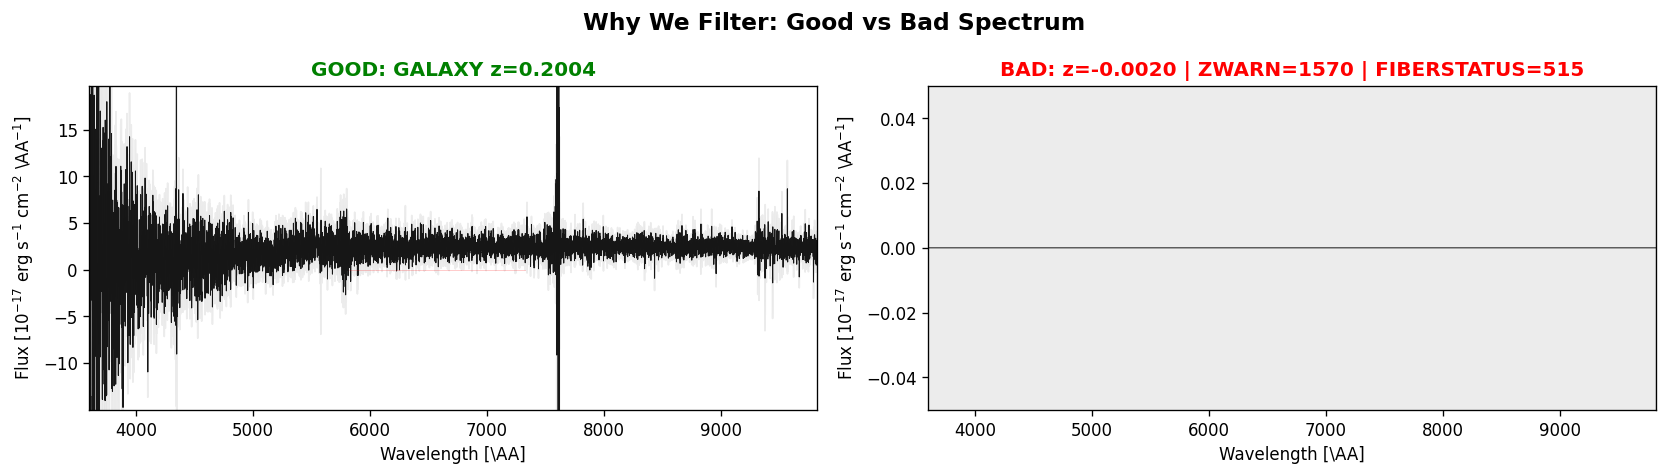


Bad spectrum details:
  TARGETID: 6
  Total flux: 0.00
  ZWARN: 1570 (non-zero = bad fit)
  FIBERSTATUS: 515 (non-zero = hardware issue)


In [8]:
# Load ALL spectra without filtering
all_spectra = load_spectra(coadd_path, redrock_path, require_good=False)

# Find a bad one (zero flux)
bad_spectra = [s for s in all_spectra if np.abs(s["flux"]).sum() == 0]

if bad_spectra:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Plot a good spectrum
    good = spectra[0]
    plot_spectrum(good, ax=axes[0])
    axes[0].set_title(f"GOOD: {good['spectype']} z={good['z']:.4f}", color='green', fontweight='bold')
    
    # Plot a bad spectrum
    bad = bad_spectra[0]
    plot_spectrum(bad, ax=axes[1])
    axes[1].set_title(
        f"BAD: z={bad['z']:.4f} | ZWARN={bad['zwarn']} | FIBERSTATUS={bad['fiberstatus']}",
        color='red', fontweight='bold'
    )
    
    plt.suptitle("Why We Filter: Good vs Bad Spectrum", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nBad spectrum details:")
    print(f"  TARGETID: {bad.get('index', 'N/A')}")
    print(f"  Total flux: {np.abs(bad['flux']).sum():.2f}")
    print(f"  ZWARN: {bad['zwarn']} (non-zero = bad fit)")
    print(f"  FIBERSTATUS: {bad['fiberstatus']} (non-zero = hardware issue)")
else:
    print("No zero-flux spectra found in this file.")

## Step 8: Emission Line Identification

Let's identify strong emission lines in a galaxy spectrum and mark them.

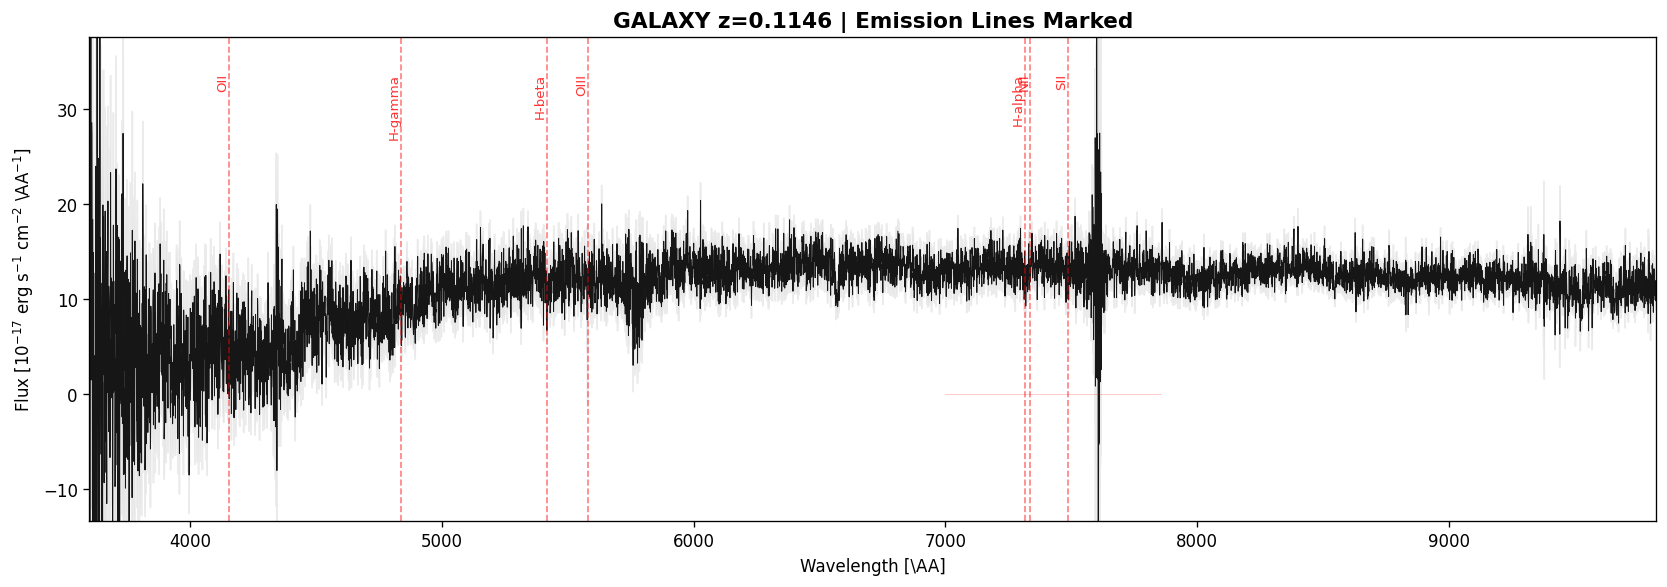


Observed wavelengths of emission lines (z=0.1146):
  H-alpha   : 6563.0 Å → 7315.2 Å
  H-beta    : 4861.0 Å → 5418.2 Å
  H-gamma   : 4340.0 Å → 4837.4 Å
  OIII      : 5007.0 Å → 5580.9 Å
  NII       : 6584.0 Å → 7338.6 Å
  SII       : 6717.0 Å → 7486.9 Å
  OII       : 3727.0 Å → 4154.2 Å


In [9]:
# Strong rest-frame emission lines
EMISSION_LINES = {
    "H-alpha": 6563.0,
    "H-beta": 4861.0,
    "H-gamma": 4340.0,
    "OIII": 5007.0,
    "NII": 6584.0,
    "SII": 6717.0,
    "OII": 3727.0,
}

# Find a galaxy with strong emission lines
galaxies = [s for s in spectra if s["spectype"] == "GALAXY"]
if galaxies:
    # Pick galaxy with highest flux variance (likely has strong lines)
    best_galaxy = max(galaxies, key=lambda s: np.var(s["flux"]))
    
    fig, ax = plt.subplots(figsize=(14, 5))
    plot_spectrum(best_galaxy, ax=ax)
    
    # Mark emission lines
    z = best_galaxy["z"]
    for name, rest_wave in EMISSION_LINES.items():
        obs_wave = rest_wave * (1 + z)
        if best_galaxy["wavelength"].min() < obs_wave < best_galaxy["wavelength"].max():
            ax.axvline(obs_wave, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.text(
                obs_wave, ax.get_ylim()[1] * 0.9,
                name, rotation=90, fontsize=8,
                verticalalignment='top', horizontalalignment='right',
                color='red', alpha=0.8
            )
    
    ax.set_title(
        f"GALAXY z={z:.4f} | Emission Lines Marked",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    
    print(f"\nObserved wavelengths of emission lines (z={z:.4f}):")
    for name, rest_wave in EMISSION_LINES.items():
        obs_wave = rest_wave * (1 + z)
        print(f"  {name:10s}: {rest_wave:.1f} Å → {obs_wave:.1f} Å")
else:
    print("No galaxies in this sample.")

## Summary

**What we learned:**
- DESI spectra have 3 camera bands (B, R, Z) that must be stitched
- ~42% of raw spectra are bad (bad fiber, bad redshift, zero flux)
- After filtering, we have **25 good spectra** with reliable redshifts
- Object types: STARS (z≈0), GALAXIES (z=0.1–1.0), QSOs (rare)
- Emission lines shift to longer wavelengths at higher redshift

**Next step:** Build the spectrum tokenizer (Phase 2) to compress these spectra into discrete tokens.